In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.optimize import curve_fit
from joblib import Parallel, delayed
import matplotlib.colors as colors

%matplotlib widget

In [19]:
KrMap3D = pd.read_hdf('MC_3Dmap_median.h5')
KrMap3D = KrMap3D[["mu", "dt", "x", "y"]]
KrMap3D = KrMap3D.rename(columns={"dt": "dt_bin","x" : "x_bin","y" : "y_bin"})

In [88]:
nbins = 101

# Define bin edges using np.linspace for x and y -- These are binning of the main Kr map
x_bins_og = np.linspace(-500, 500, nbins)  # 10 evenly spaced bins between -500 and 500
y_bins_og = np.linspace(-500, 500, nbins)
dt_bins_og = np.linspace(20, 1350, 11)

# Calculate bin centers
x_bins_c_og = (x_bins_og[:-1] + x_bins_og[1:]) / 2  # Bin centers for x
y_bins_c_og = (y_bins_og[:-1] + y_bins_og[1:]) / 2  # Bin centers for y
dt_bins_c_og = (dt_bins_og[:-1] + dt_bins_og[1:]) / 2


# --- Flexible binning

nbins = 101

# Define bin edges using np.linspace for x and y
x_bins = np.linspace(-500, 500, nbins)  # 10 evenly spaced bins between -500 and 500
y_bins = np.linspace(-500, 500, nbins)
dt_bins = np.linspace(20, 1350, 11)

# Calculate bin centers
x_bins_c = (x_bins[:-1] + x_bins[1:]) / 2  # Bin centers for x
y_bins_c = (y_bins[:-1] + y_bins[1:]) / 2  # Bin centers for y
dt_bins_c = (dt_bins[:-1] + dt_bins[1:]) / 2

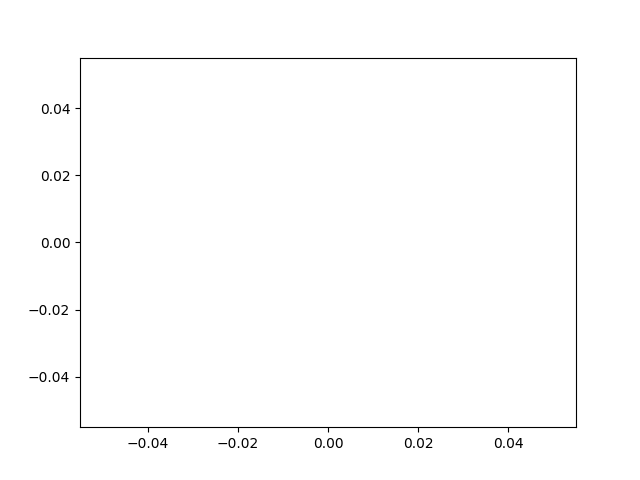

In [21]:
plt.figure()
index = 1
plt.scatter(KrMap3D[KrMap3D.dt_bin == dt_bins_c[index]].x_bin, KrMap3D[KrMap3D.dt_bin == dt_bins_c[index]].y_bin, c = KrMap3D[KrMap3D.dt_bin == dt_bins_c[index]].mu)

In [77]:
def process_single_file(f, mode):
    try:
        if (mode == "sophronia"):
            df = pd.read_hdf(f, "RECO/Events")
            df = df[["event", "X", "Y", "Z", "E", "Q"]]
            return df
        elif(mode == "nexus"):
            df = pd.read_hdf(f, "MC/particles")
            return df[df.primary == 1]
        else:
            df = pd.read_hdf(f, "DST/Events")
            df = df[["event", "S2e", "DT", "X", "Y", "S2q"]]
            df = df.rename(columns={"DT": "dt_bin","X" : "x_bin","Y" : "y_bin", "S2e": "mu"})
            return df
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel(filepath, mode, nfiles):
    files = glob.glob(filepath)[0:nfiles]
    results = Parallel(n_jobs=-1)( delayed(process_single_file)(f, mode) for f in files)
    results = [res for res in results if res is not None]
    
    return pd.concat(results)

,event,X,Y,Z,E,Q,dt,x_bin,y_bin,dt_bin
0,926800,11.475,-483.425,8.440060,710.206789,9.681160,9.701219,15.0,-485.0,NaN
1,926800,27.025,-483.425,8.440060,680.437651,9.275363,9.701219,25.0,-485.0,NaN
2,926800,11.475,-483.425,11.628338,857.284513,10.608696,13.365906,15.0,-485.0,NaN
3,926801,42.575,-94.675,684.206497,424.983621,5.333333,786.444250,45.0,-95.0,751.5
4,926801,42.575,-79.125,684.206497,725.243745,9.101449,786.444250,45.0,-75.0,751.5
...,...,...,...,...,...,...,...,...,...,...
41260,584599,-144.025,-296.825,1169.066524,595.020334,6.782609,1343.754625,-145.0,-295.0,1283.5
41261,584599,-144.025,-281.275,1169.066524,696.733183,7.942029,1343.754625,-145.0,-285.0,1283.5
41262,584599,-144.025,-265.725,1169.066524,818.788602,9.333333,1343.754625,-145.0,-265.0,1283.5
41263,584599,-128.475,-327.925,1169.066524,528.906940,6.028986,1343.754625,-125.0,-325.0,1283.5


,event,X,Y,Z,E,Q,dt,x_bin,y_bin,dt_bin,mu,Ecorr
0,926801,42.575,-94.675,684.206497,424.983621,5.333333,786.444250,45.0,-95.0,751.5,10614.861816,0.040037
1,926801,42.575,-94.675,687.534519,441.952936,8.811594,790.269563,45.0,-95.0,751.5,10614.861816,0.041635
2,926801,42.575,-94.675,690.900549,538.111298,14.434782,794.138562,45.0,-95.0,751.5,10614.861816,0.050694
3,926801,42.575,-94.675,694.275986,691.901965,17.913044,798.018375,45.0,-95.0,751.5,10614.861816,0.065182
4,926801,42.575,-94.675,697.668551,750.836137,20.869566,801.917875,45.0,-95.0,751.5,10614.861816,0.070734
...,...,...,...,...,...,...,...,...,...,...,...,...
38748090,780066,493.525,262.975,69.645525,444.049335,12.057971,80.052328,495.0,265.0,86.5,NaN,NaN
38748091,44873,338.025,418.475,413.782549,155.002360,5.391304,475.612125,335.0,415.0,485.5,NaN,NaN
38748092,773922,244.725,480.675,477.675729,521.282753,21.507246,549.052563,245.0,485.0,485.5,NaN,NaN
38748093,148951,369.125,387.375,140.508045,146.033627,5.043478,161.503500,365.0,385.0,219.5,NaN,NaN


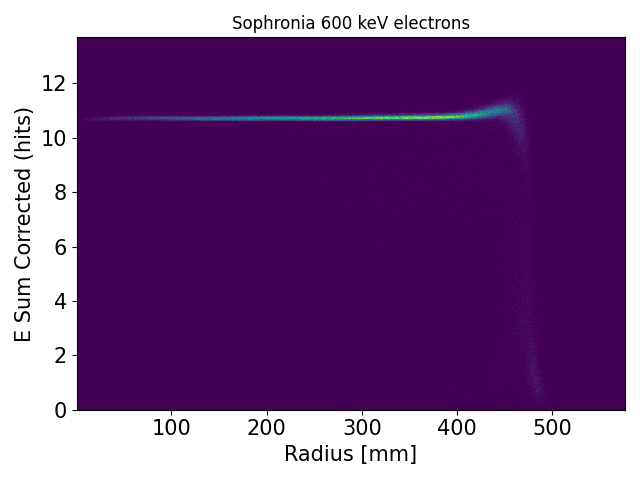

In [90]:
# Correct 600 keV electron tracks with provided 3D Kr Map

# lets see if we can explore the energy correction for the 600 keV tracks
elec_samp = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5", "sophronia", 1000)
elec_samp["dt"] = elec_samp["Z"] / 0.87  # Convert Z to drift time using drift velocity

# Bin the data
elec_samp['x_bin']  = pd.cut(elec_samp['X'],  bins=x_bins_og,  labels=x_bins_c_og)
elec_samp['y_bin']  = pd.cut(elec_samp['Y'],  bins=y_bins_og,  labels=y_bins_c_og)
elec_samp['dt_bin'] = pd.cut(elec_samp['dt'], bins=dt_bins_og, labels=dt_bins_c_og)

display(elec_samp)

# Merge the Kr map on the dataframe
merged_df = pd.merge(elec_samp, KrMap3D, on=["x_bin", "y_bin", "dt_bin"], how="inner")
merged_df["Ecorr"] = merged_df["E"] / merged_df["mu"]
display(merged_df)

# Event level information
merged_df_avg = merged_df.groupby('event').agg({'X': 'mean','Y': 'mean','Z': 'median',"E" : "sum",'Ecorr' : 'sum'}).reset_index()
merged_df_avg['radius'] = np.sqrt(merged_df_avg['X']**2 + merged_df_avg['Y']**2)


plt.figure()
# merged_df_avg = merged_df_avg[merged_df_avg.Ecorr < 25]
plt.hist2d(merged_df_avg.radius, merged_df_avg.Ecorr, bins= 500);
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

In [92]:
# Lets try to make a Kr map using the Pyrrha Kr events

# dsts = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/dorothea/*.h5")
dsts = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m_Pyrrha/dorothea/*.h5", "dorothea", 6000)
print("Number of events:", len(dsts.event.unique()))

dsts = dsts[dsts["dt_bin"] > 0]
dsts = dsts[dsts["mu"] > 3.5e3]
print("Number of events after cuts:", len(dsts.event.unique()))
display(dsts)

# Bin the Kr events
dsts['x_bin']  = pd.cut(dsts['x_bin'],   bins=x_bins,  labels=x_bins_c)
dsts['y_bin']  = pd.cut(dsts['y_bin'],   bins=y_bins,  labels=y_bins_c)
dsts['dt_bin'] = pd.cut(dsts['dt_bin'],  bins=dt_bins, labels=dt_bins_c)

Kr_Map_Pyrrha = dsts.groupby(["x_bin", "y_bin", "dt_bin"]).agg({'mu' : 'median', "S2q": "median"}).reset_index()

display(Kr_Map_Pyrrha)

Number of events: 3422130
Number of events after cuts: 3417522


,event,mu,dt_bin,x_bin,y_bin,S2q
0,2968000,8009.481445,7.437098,-34.249919,142.570486,250.434784
1,2968001,7149.002930,486.412537,265.004712,-267.732986,189.449280
2,2968002,4380.645508,1133.393066,-88.413130,-466.557374,89.623192
3,2968003,6972.148926,1004.481750,131.393965,391.911971,145.043472
4,2968004,6659.060547,498.447327,-223.689122,377.272887,251.014496
...,...,...,...,...,...,...
1025,2512995,4433.782715,1228.470825,418.315650,-231.217061,88.347832
1026,2512996,7718.683105,684.495056,-55.680128,257.990267,243.594208
1027,2512997,7601.187500,508.439911,-161.820733,-280.856963,185.449280
1028,2512998,6642.121094,1111.392090,309.923707,-301.908230,204.115921


,x_bin,y_bin,dt_bin,mu,S2q
0,-495.0,-495.0,86.5,NaN,NaN
1,-495.0,-495.0,219.5,NaN,NaN
2,-495.0,-495.0,352.5,NaN,NaN
3,-495.0,-495.0,485.5,NaN,NaN
4,-495.0,-495.0,618.5,NaN,NaN
...,...,...,...,...,...
99995,495.0,495.0,751.5,NaN,NaN
99996,495.0,495.0,884.5,NaN,NaN
99997,495.0,495.0,1017.5,NaN,NaN
99998,495.0,495.0,1150.5,NaN,NaN


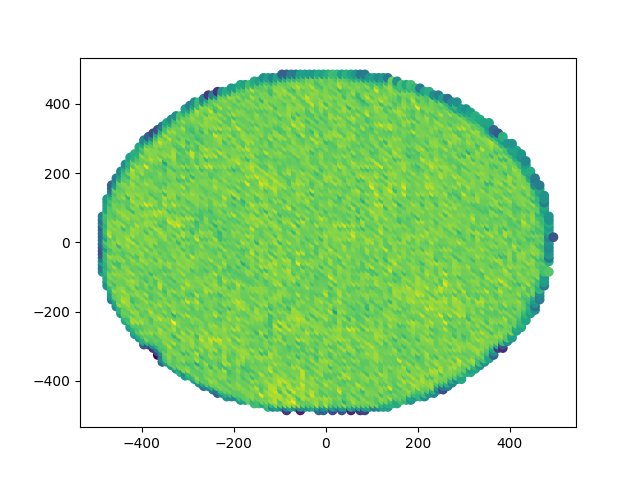

In [80]:
index = 15
# plt.figure()
# plt.scatter(Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].x_bin, Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].y_bin, c = Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].mu)
plt.figure()
plt.scatter(Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].x_bin, Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].y_bin, c = Kr_Map_Pyrrha[Kr_Map_Pyrrha.dt_bin == dt_bins_c[index]].S2q)

,event,X,Y,Z,E,Q,dt,x_bin,y_bin,dt_bin,mu,S2q
0,926801,42.575,-94.675,684.206497,424.983621,5.333333,786.444250,45.0,-95.0,751.5,7831.847656,194.028992
1,926801,42.575,-94.675,687.534519,441.952936,8.811594,790.269563,45.0,-95.0,751.5,7831.847656,194.028992
2,926801,42.575,-94.675,690.900549,538.111298,14.434782,794.138562,45.0,-95.0,751.5,7831.847656,194.028992
3,926801,42.575,-94.675,694.275986,691.901965,17.913044,798.018375,45.0,-95.0,751.5,7831.847656,194.028992
4,926801,42.575,-94.675,697.668551,750.836137,20.869566,801.917875,45.0,-95.0,751.5,7831.847656,194.028992
...,...,...,...,...,...,...,...,...,...,...,...,...
38748090,780066,493.525,262.975,69.645525,444.049335,12.057971,80.052328,495.0,265.0,86.5,NaN,NaN
38748091,44873,338.025,418.475,413.782549,155.002360,5.391304,475.612125,335.0,415.0,485.5,NaN,NaN
38748092,773922,244.725,480.675,477.675729,521.282753,21.507246,549.052563,245.0,485.0,485.5,NaN,NaN
38748093,148951,369.125,387.375,140.508045,146.033627,5.043478,161.503500,365.0,385.0,219.5,NaN,NaN


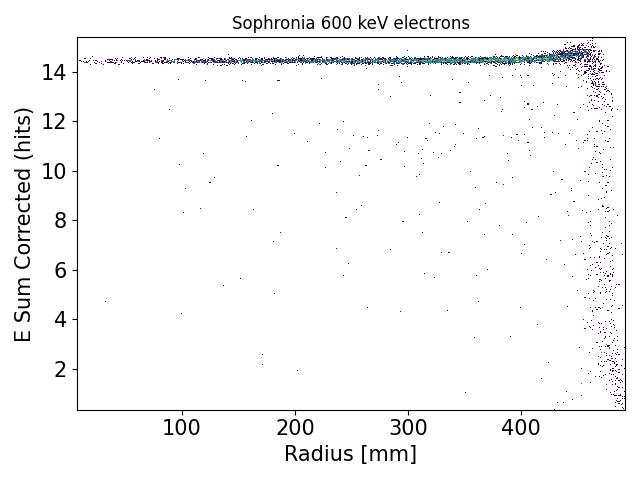

In [98]:
merged_df_pyrrha = pd.merge(elec_samp, Kr_Map_Pyrrha, on=["x_bin", "y_bin", "dt_bin"], how="inner")
display(merged_df_pyrrha)
merged_df_pyrrha["Ecorr"] = merged_df_pyrrha["E"] / merged_df_pyrrha["mu"]
# merged_df_pyrrha["Ecorr"] = merged_df_pyrrha["Ecorr"] * merged_df_pyrrha["S2q"]

merged_df_pyrrha_avg = merged_df_pyrrha.groupby('event').agg({'X': 'mean','Y': 'mean','Z': 'median',"E" : "sum",'Ecorr' : 'sum'}).reset_index()
merged_df_pyrrha_avg['radius'] = np.sqrt(merged_df_pyrrha_avg['X']**2 + merged_df_pyrrha_avg['Y']**2)

plt.figure()
# plt.hist2d(merged_df_pyrrha_avg.radius, merged_df_pyrrha_avg.Ecorr, bins= 500, norm = colors.LogNorm());
plt.hist2d(merged_df_pyrrha_avg[(merged_df_pyrrha_avg.Z > 150) & (merged_df_pyrrha_avg.Z < 200)].radius, merged_df_pyrrha_avg[(merged_df_pyrrha_avg.Z > 150) & (merged_df_pyrrha_avg.Z < 200)].Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

,event,X,Y,Z,E,Q,dt,x_bin,y_bin,dt_bin,mu,Ecorr
0,699000,291.375,-156.875,593.755262,579.393977,5.855072,682.477312,295.0,-155.0,671.7,7394.830078,0.078351
1,589800,291.375,-156.875,592.429654,562.940093,6.028985,680.953625,295.0,-155.0,671.7,7394.830078,0.076126
2,589800,291.375,-156.875,595.758491,1378.169011,7.710145,684.779875,295.0,-155.0,671.7,7394.830078,0.186369
3,487224,291.375,-156.875,582.097914,898.221510,15.478261,669.078062,295.0,-155.0,671.7,7394.830078,0.121466
4,487224,291.375,-156.875,585.473623,581.459954,12.289855,672.958188,295.0,-155.0,671.7,7394.830078,0.078631
...,...,...,...,...,...,...,...,...,...,...,...,...
8482667,418956,477.975,169.675,601.438504,219.396451,5.507246,691.308625,475.0,165.0,698.3,NaN,NaN
8482668,162027,244.725,496.225,1015.037809,1251.993906,6.898551,1166.710125,245.0,495.0,1177.1,NaN,NaN
8482669,162210,-423.925,-281.275,647.453021,531.614891,5.565217,744.198875,-425.0,-285.0,751.5,NaN,NaN
8482670,162272,-299.525,-421.225,240.355743,330.222971,9.333333,276.270969,-295.0,-425.0,272.7,NaN,NaN


/tmp/ipykernel_2874508/3174762740.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.hist2d(merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].radius, merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].Ecorr, bins= 500, norm = colors.LogNorm());
/tmp/ipykernel_2874508/3174762740.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.hist2d(merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].radius, merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].Ecorr, bins= 500, norm = colors.LogNorm());
/tmp/ipykernel_2874508/3174762740.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.hist2d(merged_df_kr_avg_hits[merged_df_kr_hits.Z > 1000].radius, merged_df_kr_avg_hits[merged_df_kr_hits.Z > 1000].Ecorr, bins= 500, norm = colors.LogNorm());
/tmp/ipykernel_2874508/3174762740.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.hist2d(merged_df_kr_avg_hits[merged_df_

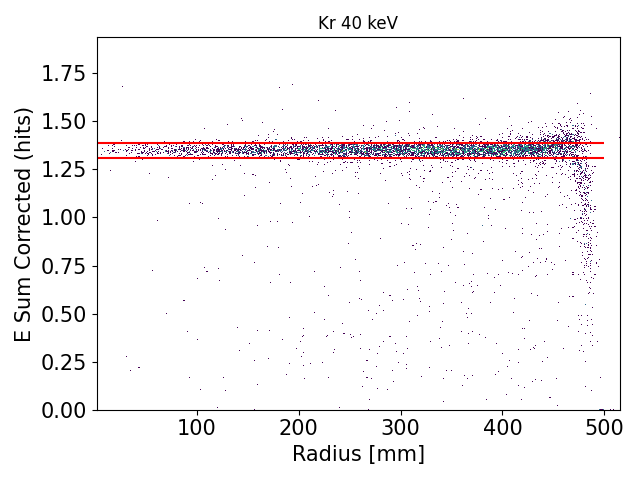

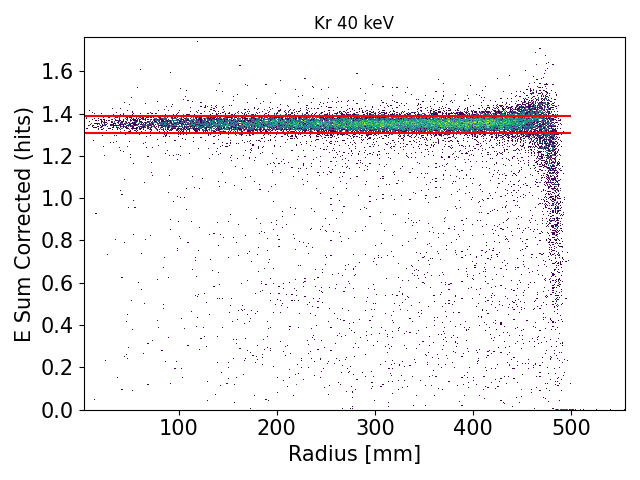

In [40]:
# Lets see what happens when we self correct the Kr-83m events
kr_samp = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/sophronia/*.h5", "sophronia", 1000)
kr_samp["dt"] = kr_samp["Z"] / 0.87  # Convert Z to drift time using drift velocity

kr_samp['x_bin']  = pd.cut(kr_samp['X'], bins=x_bins, labels=x_bins_c)
kr_samp['y_bin']  = pd.cut(kr_samp['Y'], bins=y_bins, labels=y_bins_c)
kr_samp['dt_bin'] = pd.cut(kr_samp['dt'], bins=dt_bins, labels=dt_bins_c)

merged_df_kr_hits = pd.merge(kr_samp, Kr_Map_Pyrrha, on=["x_bin", "y_bin", "dt_bin"], how="inner")
merged_df_kr_hits["Ecorr"] = merged_df_kr_hits["E"] / merged_df_kr_hits["mu"]
merged_df_kr_avg_hits = merged_df_kr_hits.groupby('event').agg({'X': 'mean','Y': 'mean','Z': 'median',"E" : "sum",'Ecorr' : 'sum', "Q": "sum"}).reset_index()
merged_df_kr_avg_hits['radius'] = np.sqrt(merged_df_kr_avg_hits['X']**2 + merged_df_kr_avg_hits['Y']**2)
display(merged_df_kr_hits)

plt.figure()

plt.hist2d(merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].radius, merged_df_kr_avg_hits[merged_df_kr_hits.Z < 20].Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Kr 40 keV")
plt.tight_layout()
plt.hlines(1.386, 0, 500, color = "red")
plt.hlines(1.31, 0, 500, color = "red")

plt.figure()
plt.hist2d(merged_df_kr_avg_hits[merged_df_kr_hits.Z > 1000].radius, merged_df_kr_avg_hits[merged_df_kr_hits.Z > 1000].Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Kr 40 keV")
plt.tight_layout()
plt.hlines(1.386, 0, 500, color = "red")
plt.hlines(1.31, 0, 500, color = "red")

In [28]:
# Lets try to make a Kr map with Uneven bin sizes in X,Y for a given Z

dsts_copy = dsts.copy()


def BinUneaven(df):

    # Make the dt bins first
    df['dt_bin'] = pd.cut(df['dt_bin'], bins=dt_bins, labels=dt_bins_c)

    binned_slices = []

    # Iterate through every single unique dt bin category
    for dt_val, group in df.groupby('dt_bin', observed=False):
        if group.empty:
            continue
            
        # Dynamically calculate the number of spatial bins based on the dt value
        # Example logic: higher dt = fewer bins (larger bin sizes)
        # If dt_val is 20, n_spatial_bins = 100. If dt_val is 1350, n_spatial_bins = ~33.
        n_spatial_bins = int(1350 / (2*np.sqrt(float(dt_val)*0.87))) 
        n_spatial_bins = max(n_spatial_bins, 10) # Ensure a floor minimum of 10 bins
        # print("dt val, nbins", dt_val, n_spatial_bins)
        
        # Generate dynamic spatial edges and centers
        dyn_x_edges = np.linspace(-500, 500, n_spatial_bins + 1)
        dyn_x_centers = (dyn_x_edges[:-1] + dyn_x_edges[1:]) / 2
        
        # Apply to the group slice
        group_copy = group.copy()
        group_copy['x_bin'] = pd.cut(group_copy['x_bin'], bins=dyn_x_edges, labels=dyn_x_centers)
        group_copy['y_bin'] = pd.cut(group_copy['y_bin'], bins=dyn_x_edges, labels=dyn_x_centers)
        
        binned_slices.append(group_copy)

    dsts_binned = pd.concat(binned_slices).sort_index()
    return dsts_binned

dsts_binned = BinUneaven(dsts_copy)

Kr_Map_Uneaven = dsts_binned.groupby(["x_bin", "y_bin", "dt_bin"]).agg({'mu' : 'median'}).reset_index()
display(Kr_Map_Uneaven)

,x_bin,y_bin,dt_bin,mu
0,-491.803279,-491.803279,33.3,NaN
1,-491.803279,-491.803279,59.9,NaN
2,-491.803279,-491.803279,86.5,NaN
3,-491.803279,-491.803279,113.1,NaN
4,-491.803279,-491.803279,139.7,NaN
...,...,...,...,...
70211245,496.000000,496.000000,1230.3,NaN
70211246,496.000000,496.000000,1256.9,NaN
70211247,496.000000,496.000000,1283.5,NaN
70211248,496.000000,496.000000,1310.1,NaN


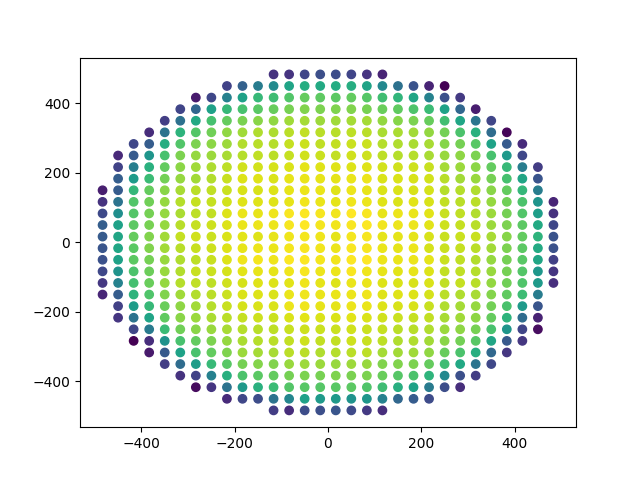

In [29]:
plt.figure()
index = 20
plt.scatter(Kr_Map_Uneaven[Kr_Map_Uneaven.dt_bin == dt_bins_c[index]].x_bin, Kr_Map_Uneaven[Kr_Map_Uneaven.dt_bin == dt_bins_c[index]].y_bin, c = Kr_Map_Uneaven[Kr_Map_Uneaven.dt_bin == dt_bins_c[index]].mu)

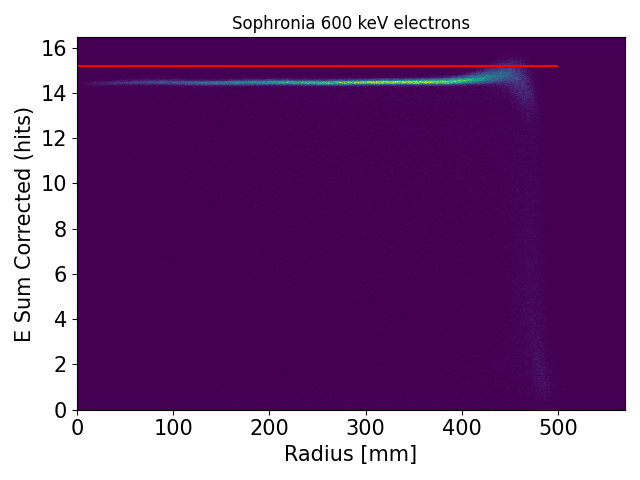

In [30]:
elec_samp = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5","sophronia", 1000)
elec_samp["dt_bin"] = elec_samp["Z"] / 0.87  # Convert Z to drift time using drift velocity
elec_samp = elec_samp.rename(columns={"X" : "x_bin","Y" : "y_bin"})

elec_samp_binned = BinUneaven(elec_samp)

merged_df = pd.merge(elec_samp_binned, Kr_Map_Uneaven, on=["x_bin", "y_bin", "dt_bin"], how="inner")
merged_df["Ecorr"] = merged_df["E"] / merged_df["mu"]

# Event level information
merged_df_avg = merged_df.groupby('event').agg({'x_bin': 'mean','y_bin': 'mean','Z': 'median',"E" : "sum",'Ecorr' : 'sum'}).reset_index()
merged_df_avg['radius'] = np.sqrt(merged_df_avg['x_bin']**2 + merged_df_avg['y_bin']**2)

plt.figure()
# merged_df_avg = merged_df_avg[merged_df_avg.Ecorr < 25]
plt.hist2d(merged_df_avg.radius, merged_df_avg.Ecorr, bins= 500);
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()
plt.hlines(15.2, 0, 500, color = "red")

,event,X,Y,Z,E,dt_bin,radius,x_bin,y_bin,mu,Ecorr
0,926801.0,42.575,-94.675,684.206497,424.983621,778.1,103.807448,45.0,-95.0,7852.358398,0.054122
1,926801.0,42.575,-94.675,687.534519,441.952936,778.1,103.807448,45.0,-95.0,7852.358398,0.056283
2,388875.0,42.575,-94.675,665.662013,245.553194,778.1,103.807448,45.0,-95.0,7852.358398,0.031271
3,388875.0,42.575,-94.675,672.444478,192.034065,778.1,103.807448,45.0,-95.0,7852.358398,0.024456
4,429132.0,42.575,-94.675,666.604875,530.719394,778.1,103.807448,45.0,-95.0,7852.358398,0.067587
...,...,...,...,...,...,...,...,...,...,...,...
15309186,313139.0,244.725,-141.325,93.060671,811.927171,113.1,282.600568,245.0,-145.0,7628.257812,0.106437
15309187,313139.0,244.725,-141.325,96.576872,1066.406268,113.1,282.600568,245.0,-145.0,7628.257812,0.139797
15309188,313139.0,244.725,-141.325,99.567143,439.679484,113.1,282.600568,245.0,-145.0,7628.257812,0.057638
15309189,105737.0,244.725,-141.325,89.840584,2153.468711,113.1,282.600568,245.0,-145.0,7628.257812,0.282302


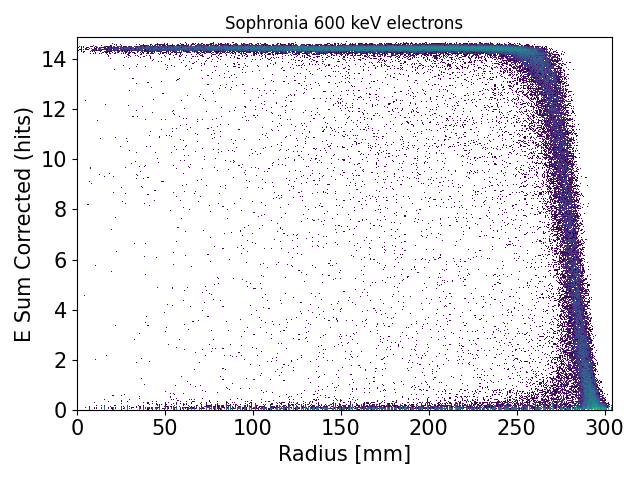

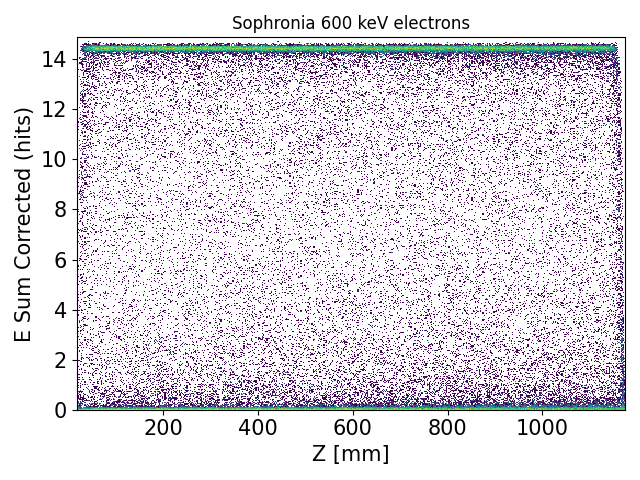

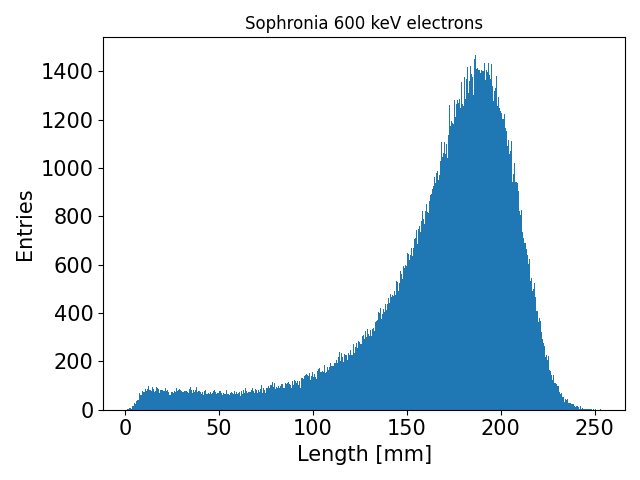

In [37]:
# lets try and apply a radial cut to the electron events and correct them to see if we can reproduce the eddge effect
elec_samp = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5","sophronia", 1000)
elec_samp["dt_bin"] = elec_samp["Z"] / 0.87  # Convert Z to drift time using drift velocity

elec_samp['radius'] = np.sqrt(elec_samp['X']**2 + elec_samp['Y']**2)
elec_samp = elec_samp[elec_samp.radius < 300]


elec_samp_nexus = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5", "nexus", 1000)
elec_samp_nexus = elec_samp_nexus[["event_id", "initial_x", "initial_y", "initial_z", "kin_energy", "length"]]
elec_samp_nexus["radius"] = np.sqrt(elec_samp_nexus["initial_x"]**2 + elec_samp_nexus["initial_y"]**2)
# elec_samp_nexus = elec_samp_nexus[elec_samp_nexus.radius < 300]
# elec_samp_nexus = elec_samp_nexus[ (elec_samp_nexus.initial_z > 70) & (elec_samp_nexus.initial_z < 1110)]
elec_samp = elec_samp[elec_samp.event.isin(elec_samp_nexus.event_id)]

# Bin the data
elec_samp['x_bin']  = pd.cut(elec_samp['X'],  bins=x_bins,  labels=x_bins_c)
elec_samp['y_bin']  = pd.cut(elec_samp['Y'],  bins=y_bins,  labels=y_bins_c)
elec_samp = elec_samp.astype(float)
elec_samp['dt_bin'] = pd.cut(elec_samp['dt_bin'], bins=dt_bins, labels=dt_bins_c)


# Merge the Kr map on the dataframe
merged_df = pd.merge(elec_samp, Kr_Map_Pyrrha, on=["x_bin", "y_bin", "dt_bin"], how="inner")
merged_df["Ecorr"] = merged_df["E"] / merged_df["mu"]
display(merged_df)

# Event level information
merged_df_avg = merged_df.groupby('event').agg({'x_bin': 'mean','y_bin': 'mean','Z': 'mean',"E" : "sum",'Ecorr' : 'sum'}).reset_index()
merged_df_avg = merged_df_avg.astype(float)
merged_df_avg['radius'] = np.sqrt(merged_df_avg['x_bin']**2 + merged_df_avg['y_bin']**2)

plt.figure()
plt.hist2d(merged_df_avg.radius, merged_df_avg.Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

plt.figure()
plt.hist2d(merged_df_avg.Z, merged_df_avg.Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Z [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

plt.figure()
plt.hist(elec_samp_nexus.length, bins= 500);
plt.xlabel("Length [mm]", fontsize = 15)
plt.ylabel("Entries", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()



,event,X,Y,Z,E,Q,dt_bin,radius,x_bin,y_bin,mu,Ecorr
0,699000.0,291.375,-156.875,593.755262,579.393977,5.855072,671.7,330.921677,295.0,-155.0,7394.830078,0.078351
1,589800.0,291.375,-156.875,592.429654,562.940093,6.028985,671.7,330.921677,295.0,-155.0,7394.830078,0.076126
2,589800.0,291.375,-156.875,595.758491,1378.169011,7.710145,671.7,330.921677,295.0,-155.0,7394.830078,0.186369
3,487224.0,291.375,-156.875,582.097914,898.221510,15.478261,671.7,330.921677,295.0,-155.0,7394.830078,0.121466
4,487224.0,291.375,-156.875,585.473623,581.459954,12.289855,671.7,330.921677,295.0,-155.0,7394.830078,0.078631
...,...,...,...,...,...,...,...,...,...,...,...,...
8482667,418956.0,477.975,169.675,601.438504,219.396451,5.507246,698.3,507.197897,475.0,165.0,NaN,NaN
8482668,162027.0,244.725,496.225,1015.037809,1251.993906,6.898551,1177.1,553.289776,245.0,495.0,NaN,NaN
8482669,162210.0,-423.925,-281.275,647.453021,531.614891,5.565217,751.5,508.751443,-425.0,-285.0,NaN,NaN
8482670,162272.0,-299.525,-421.225,240.355743,330.222971,9.333333,272.7,516.861419,-295.0,-425.0,NaN,NaN


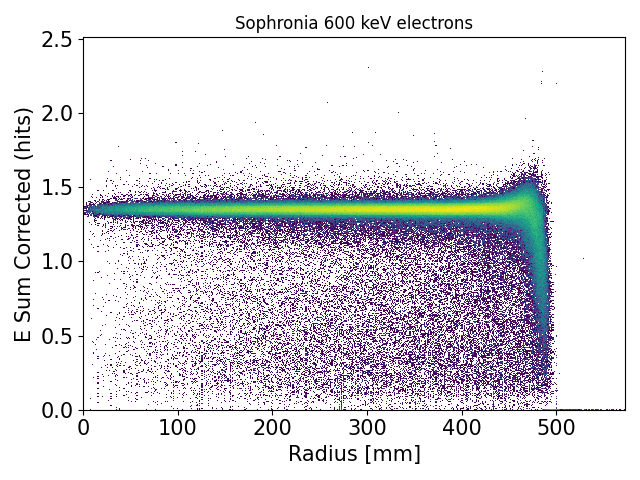

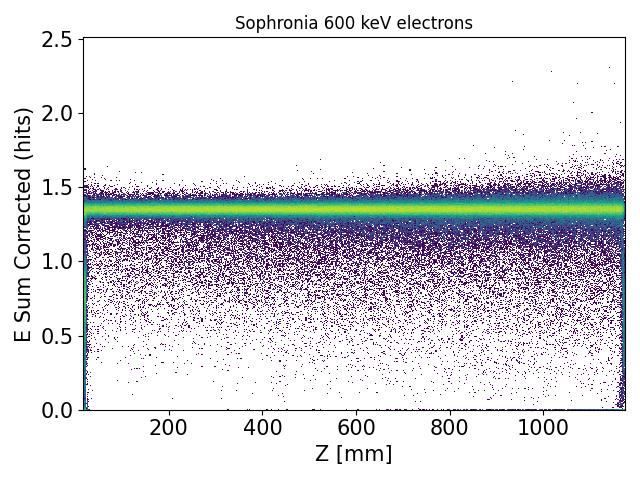

In [49]:
# lets try and apply a radial cut to the electron events and correct them to see if we can reproduce the eddge effect
elec_samp = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/sophronia/*.h5", "sophronia", 1000)
elec_samp["dt_bin"] = elec_samp["Z"] / 0.87  # Convert Z to drift time using drift velocity

elec_samp['radius'] = np.sqrt(elec_samp['X']**2 + elec_samp['Y']**2)
# elec_samp = elec_samp[elec_samp.radius < 400]

elec_samp_nexus = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/sophronia/*.h5", "nexus", 1000)
elec_samp_nexus = elec_samp_nexus[["event_id", "initial_x", "initial_y", "initial_z"]]
elec_samp_nexus["radius"] = np.sqrt(elec_samp_nexus["initial_x"]**2 + elec_samp_nexus["initial_y"]**2)
# elec_samp_nexus = elec_samp_nexus[elec_samp_nexus.radius < 300]
# elec_samp_nexus = elec_samp_nexus[ (elec_samp_nexus.initial_z > 50) & (elec_samp_nexus.initial_z < 1110)]
# elec_samp_nexus = elec_samp_nexus[ (elec_samp_nexus.initial_z <50)]
elec_samp = elec_samp[elec_samp.event.isin(elec_samp_nexus.event_id)]

# This will filter based on the reconstructed Z pos
# elec_samp_dorothea = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/dorothea/*.h5", "dorothea", 1000)
# elec_samp_dorothea["radius"] = np.sqrt(elec_samp_dorothea["x_bin"]**2 + elec_samp_dorothea["y_bin"]**2)
# elec_samp_dorothea = elec_samp_dorothea[elec_samp_dorothea.radius < 300]
# elec_samp_dorothea = elec_samp_dorothea[ (elec_samp_dorothea.dt_bin*0.87 > 50) & (elec_samp_dorothea.dt_bin*0.87 < 1000)]
# elec_samp = elec_samp[elec_samp.event.isin(elec_samp_dorothea.event)]


# Apply a filter to remove events generated outsude the volume

# Bin the data
elec_samp['x_bin']  = pd.cut(elec_samp['X'],  bins=x_bins,  labels=x_bins_c)
elec_samp['y_bin']  = pd.cut(elec_samp['Y'],  bins=y_bins,  labels=y_bins_c)
elec_samp = elec_samp.astype(float)
elec_samp['dt_bin'] = pd.cut(elec_samp['dt_bin'], bins=dt_bins, labels=dt_bins_c)


# Merge the Kr map on the dataframe
merged_df = pd.merge(elec_samp, Kr_Map_Pyrrha, on=["x_bin", "y_bin", "dt_bin"], how="inner")
merged_df["Ecorr"] = merged_df["E"] / merged_df["mu"]
display(merged_df)

# Event level information
merged_df_avg = merged_df.groupby('event').agg({'x_bin': 'mean','y_bin': 'mean','Z': 'mean',"E" : "sum",'Ecorr' : 'sum'}).reset_index()
merged_df_avg = merged_df_avg.astype(float)
merged_df_avg['radius'] = np.sqrt(merged_df_avg['x_bin']**2 + merged_df_avg['y_bin']**2)


plt.figure()
plt.hist2d(merged_df_avg.radius, merged_df_avg.Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

plt.figure()
plt.hist2d(merged_df_avg.Z, merged_df_avg.Ecorr, bins= 500, norm = colors.LogNorm());
plt.xlabel("Z [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()


In [50]:
elec_samp_bad = merged_df_avg[merged_df_avg.Ecorr >1.525].event.unique()
elec_samp_good = merged_df_avg[(merged_df_avg.Ecorr >1.3) & (merged_df_avg.Ecorr < 1.38)].event.unique()
elec_samp_filt_bad = elec_samp[elec_samp.event.isin(elec_samp_bad)]
elec_samp_filt_good = elec_samp[elec_samp.event.isin(elec_samp_good)]


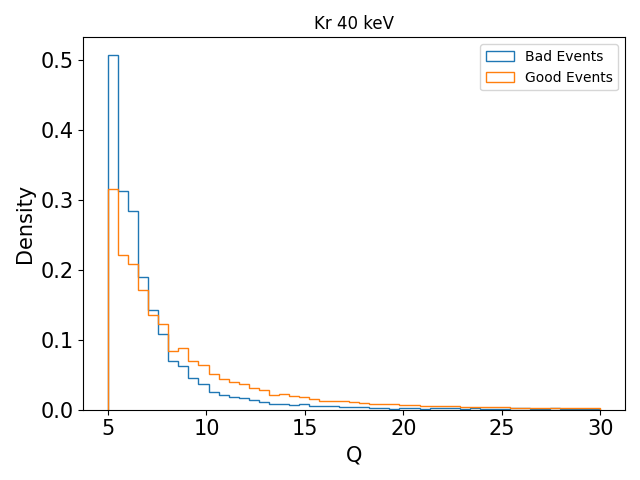

In [53]:
plt.figure()

plt.hist(elec_samp_filt_bad.Q, bins =np.linspace(5,30, 50), density=True, histtype="step", label = "Bad Events");
plt.hist(elec_samp_filt_good.Q, bins =np.linspace(5,30, 50), density=True, histtype="step", label = "Good Events");
plt.xlabel("Q", fontsize = 15)
plt.ylabel("Density", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Kr 40 keV")
plt.legend()
plt.tight_layout()

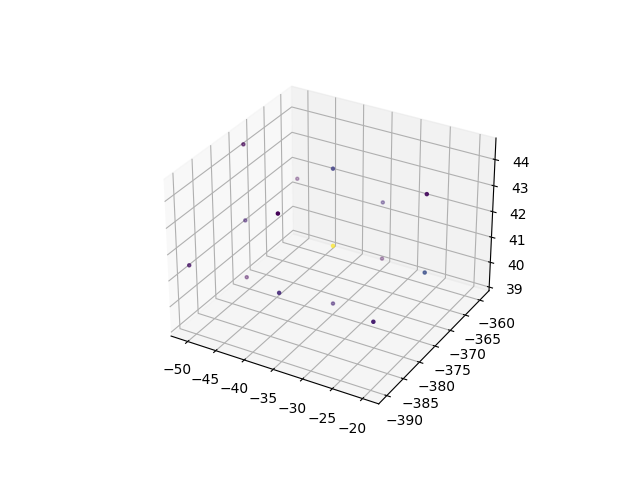

In [34]:

event_id = elec_samp_filt.event.unique()[4]
event = elec_samp_filt[elec_samp_filt.event == event_id]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(event.X, event.Y, event.Z, c=event.E, s=5)